## SVM Exercise AIES
1. Generate a 2D linearly separable dataset. Train your LinearSVM and identify the support vectors. Verify that the support vectors are the points closest to the decision boundary.
2. Vary C from 0.001 to 1000 on a noisy dataset. Plot the decision boundary for each C value. Observe the transition from wide margin (underfitting) to narrow margin (overfitting).
3. Create a dataset where class boundaries are circular (not linear). Show that a linear SVM fails. Compute the RBF kernel matrix and show that the classes become separable in the kernel-induced feature space.
4. Compare hinge loss vs logistic loss on the same dataset. Train a linear SVM and logistic regression. Count how many training points contribute to each model's decision boundary (support vectors vs all points).
5. Implement SVR (epsilon-insensitive loss). Fit it to y = sin(x) + noise. Plot the epsilon tube around the predictions and highlight the support vectors (points outside the tube).


### 1. Generate a 2D linearly separable dataset. Train your LinearSVM and identify the support vectors. Verify that the support vectors are the points closest to the decision boundary.


In [10]:
# Generate a 2D linearly separable dataset. 

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
# covnerting iris data to 2d
# taking the 'sepal length (cm)', 'sepal width (cm)' only
X=iris["data"][:,:2]
y= iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [20]:
# Train your LinearSVM and identify the support vectors.
#  Lineara SVM Does Not Provide Support Vector :)
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# svm is very sensative to data points so scaling is importanat 
clf = Pipeline([
    ("scaler",StandardScaler()),
    ("svm",LinearSVC(C=1.0))
])

In [23]:
clf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [24]:
clf.score(X_test,y_test)

0.82

In [25]:
from sklearn.svm import SVC 

In [33]:
clf2 = SVC(C=0.5)

In [34]:
clf2.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [35]:
clf2.score(X_test,y_test)

0.8

In [37]:
# support vectors
support_vectors=clf2.n_support_
support_indices=clf2.support_

In [38]:
print("Support Vector Indices:")
print(support_indices)

print("\nSupport Vectors:")
print(support_vectors)



Support Vector Indices:
[ 3  6 12 13 15 21 28 31 32 35 37 46 51 71 74 84 94 97  0  2  5  9 14 16
 19 24 25 29 34 39 40 42 53 59 60 62 66 68 69 70 72 73 75 79 85 88 90 91
 95 98 10 17 20 22 23 26 30 36 41 43 48 54 56 57 61 63 65 67 77 80 81 83
 87 89 92 93 96 99]

Support Vectors:
[18 32 28]


In [40]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Sepal Width')

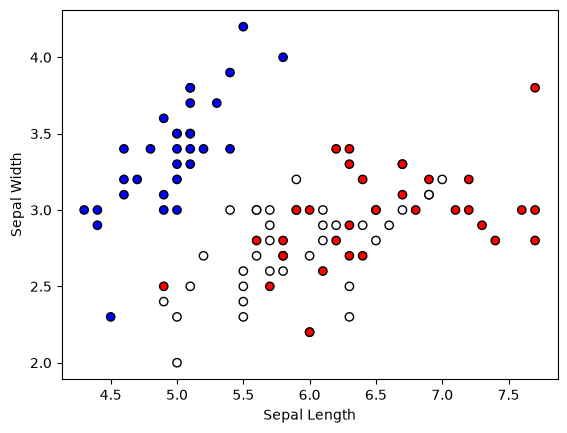

In [46]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap="bwr",    edgecolors="k")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

Support Vector Indices:
[45 29]

Support Vectors:
[[-1.03130358  8.49601591]
 [ 4.375222    4.69333885]]


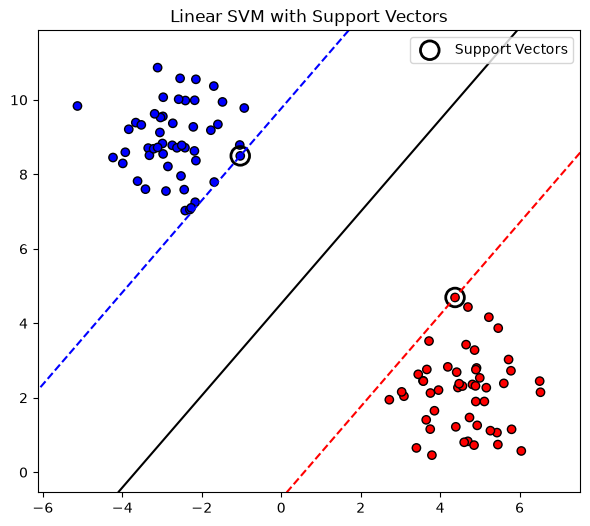


10 Closest Points to Decision Boundary:
[29 45 82 39 54 34 19 33 78 16]

Support Vector Indices:
[45 29]

Distances of Support Vectors:
[1.         0.99999997]


In [47]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Generate linearly separable dataset
X, y = make_blobs(
    n_samples=100,
    centers=2,
    cluster_std=1.0,
    random_state=42
)

# Train Linear SVM
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

clf.fit(X, y)

# Extract trained model
scaler = clf.named_steps["scaler"]
svm = clf.named_steps["svm"]

# Support vectors
support_vectors_scaled = svm.support_vectors_
support_indices = svm.support_

# Original coordinates
support_vectors = scaler.inverse_transform(support_vectors_scaled)

print("Support Vector Indices:")
print(support_indices)

print("\nSupport Vectors:")
print(support_vectors)

# Plot
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0], X[:,1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)

plt.scatter(
    support_vectors[:,0],
    support_vectors[:,1],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

# Decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

Z = svm.decision_function(grid_scaled)
Z = Z.reshape(xx.shape)

plt.contour(
    xx,
    yy,
    Z,
    levels=[-1,0,1],
    colors=["blue","black","red"],
    linestyles=["--","-","--"]
)

plt.legend()
plt.title("Linear SVM with Support Vectors")
plt.show()

# Verify closest points
distances = np.abs(svm.decision_function(scaler.transform(X)))

closest = np.argsort(distances)

print("\n10 Closest Points to Decision Boundary:")
print(closest[:10])

print("\nSupport Vector Indices:")
print(support_indices)

print("\nDistances of Support Vectors:")
print(distances[support_indices])

Support Vector Indices:
[20 25 31 36 41 57 59 84 85 88]

Support Vectors:
[[5.4 3.4]
 [5.  3. ]
 [5.4 3.4]
 [5.5 3.5]
 [4.5 2.3]
 [4.9 2.4]
 [5.2 2.7]
 [5.4 3. ]
 [6.  3.4]
 [5.6 3. ]]


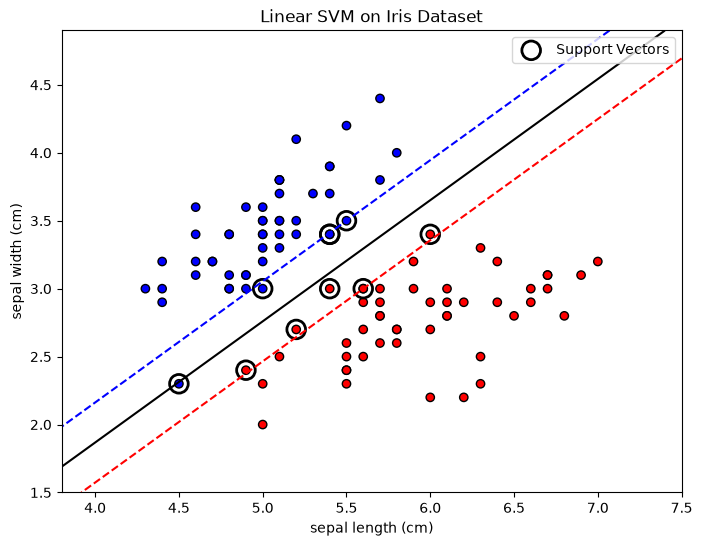


10 Closest Points to Decision Boundary:
[41 84 59 25 85 57 31 20 88 66]

Support Vector Indices:
[20 25 31 36 41 57 59 84 85 88]

Decision Function Values of Support Vectors:
[0.96325802 0.81628994 0.96325802 1.00000004 0.04633417 0.91773713
 0.80751108 0.39457003 0.85303194 1.00000001]


In [48]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Load Iris dataset
iris = load_iris()

# Take first 2 features
X = iris.data[:, :2]

# Take only Setosa and Versicolor (binary classification)
y = iris.target
mask = y < 2

X = X[mask]
y = y[mask]

# Train Linear SVM
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

clf.fit(X, y)

# Extract scaler and model
scaler = clf.named_steps["scaler"]
svm = clf.named_steps["svm"]

# Support vectors (scaled)
support_vectors_scaled = svm.support_vectors_

# Convert back to original scale
support_vectors = scaler.inverse_transform(support_vectors_scaled)

print("Support Vector Indices:")
print(svm.support_)

print("\nSupport Vectors:")
print(support_vectors)

# ---------------- Plot ----------------

plt.figure(figsize=(8,6))

# Original samples
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)

# Highlight support vectors
plt.scatter(
    support_vectors[:,0],
    support_vectors[:,1],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

# Create mesh
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

Z = svm.decision_function(grid_scaled)
Z = Z.reshape(xx.shape)

# Decision boundary and margins
plt.contour(
    xx,
    yy,
    Z,
    levels=[-1,0,1],
    colors=["blue","black","red"],
    linestyles=["--","-","--"]
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Linear SVM on Iris Dataset")
plt.legend()
plt.show()

# -------- Verification --------

scores = np.abs(svm.decision_function(scaler.transform(X)))

closest = np.argsort(scores)

print("\n10 Closest Points to Decision Boundary:")
print(closest[:10])

print("\nSupport Vector Indices:")
print(svm.support_)

print("\nDecision Function Values of Support Vectors:")
print(scores[svm.support_])

### 2. Vary C from 0.001 to 1000 on a noisy dataset. Plot the decision boundary for each C value. Observe the transition from wide margin (underfitting) to narrow margin (overfitting).

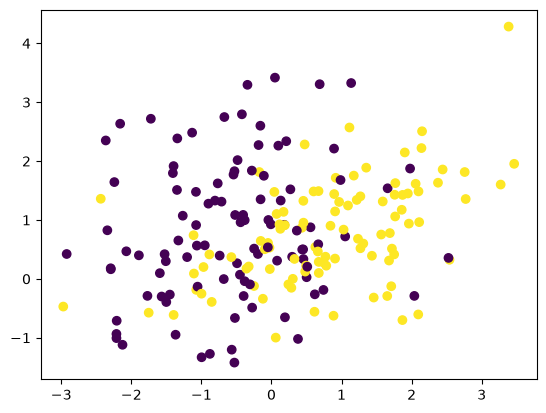

In [54]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.8,      # smaller = more overlap
    flip_y=0.15,        # 15% wrong labels (noise)
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [55]:
c_values=[0.001, 0.01, 0.1, 1,10 ,100 ,1000]

In [56]:
from mlxtend.plotting import plot_decision_regions

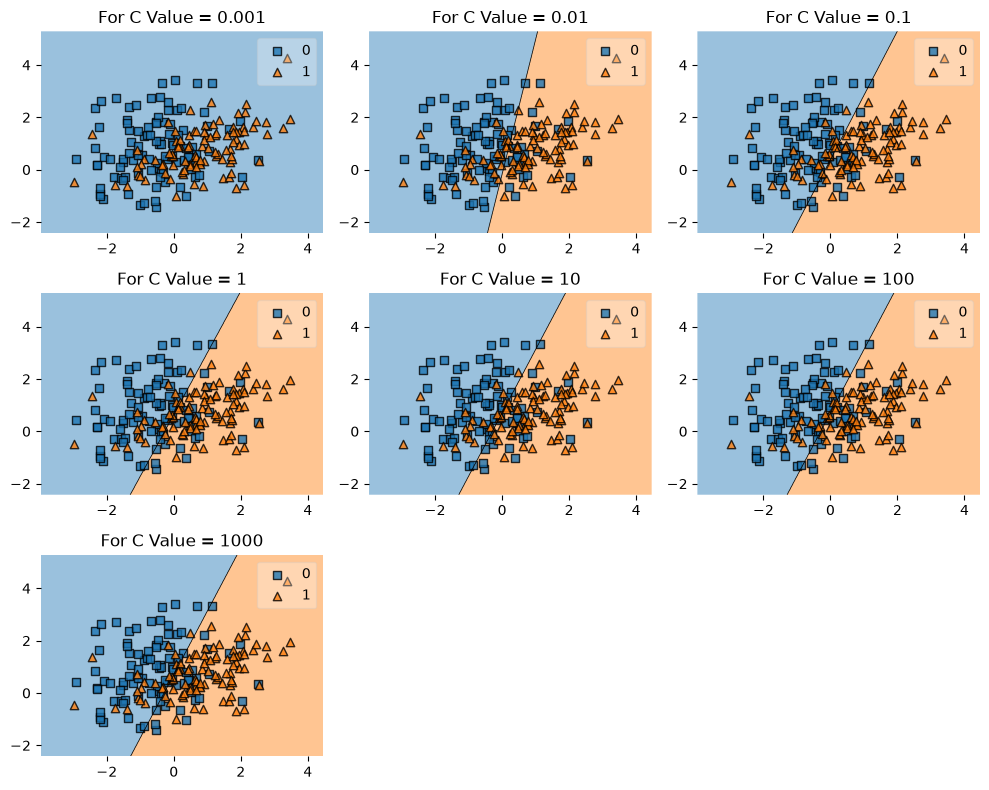

In [60]:
import matplotlib.pyplot as plt

c_values=[0.001, 0.01, 0.1, 1,10 ,100 ,1000]
plt.figure(figsize=(10, 8))
# ax=plt.subplot(3, 3, 1)   # 2 rows, 2 columns, plot number i
# print(ax)
for i, c_value in enumerate(c_values, 1):
    ax=plt.subplot(3, 3, i)   # 2 rows, 2 columns, plot number i
    clf = SVC(C=c_value,kernel="linear")
    clf.fit(X,y)
    plot_decision_regions(X,y,clf,ax=ax)
    
    plt.title(f"For C Value = {c_value}")

plt.tight_layout()
plt.show()

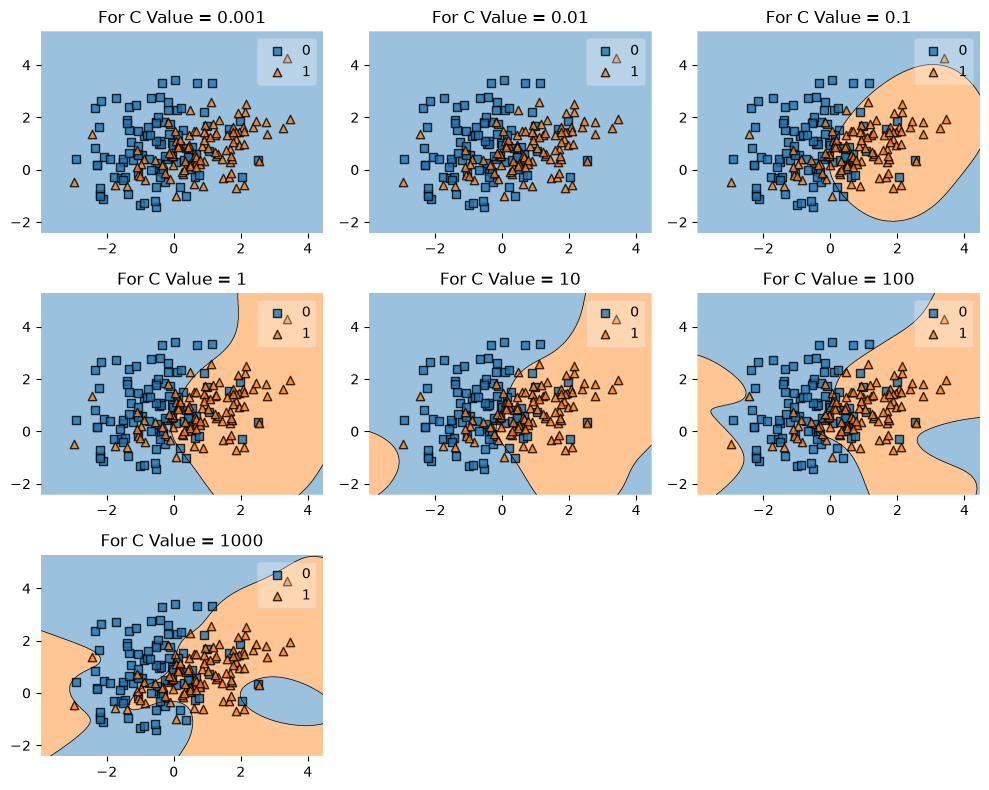

In [61]:
import matplotlib.pyplot as plt

c_values=[0.001, 0.01, 0.1, 1,10 ,100 ,1000]
plt.figure(figsize=(10, 8))
# ax=plt.subplot(3, 3, 1)   # 2 rows, 2 columns, plot number i
# print(ax)
for i, c_value in enumerate(c_values, 1):
    ax=plt.subplot(3, 3, i)   # 2 rows, 2 columns, plot number i
    clf = SVC(C=c_value,kernel="rbf")
    clf.fit(X,y)
    plot_decision_regions(X,y,clf,ax=ax)
    
    plt.title(f"For C Value = {c_value}")

plt.tight_layout()
plt.show()

In [63]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=200,
    noise=0.4,
    random_state=42
)

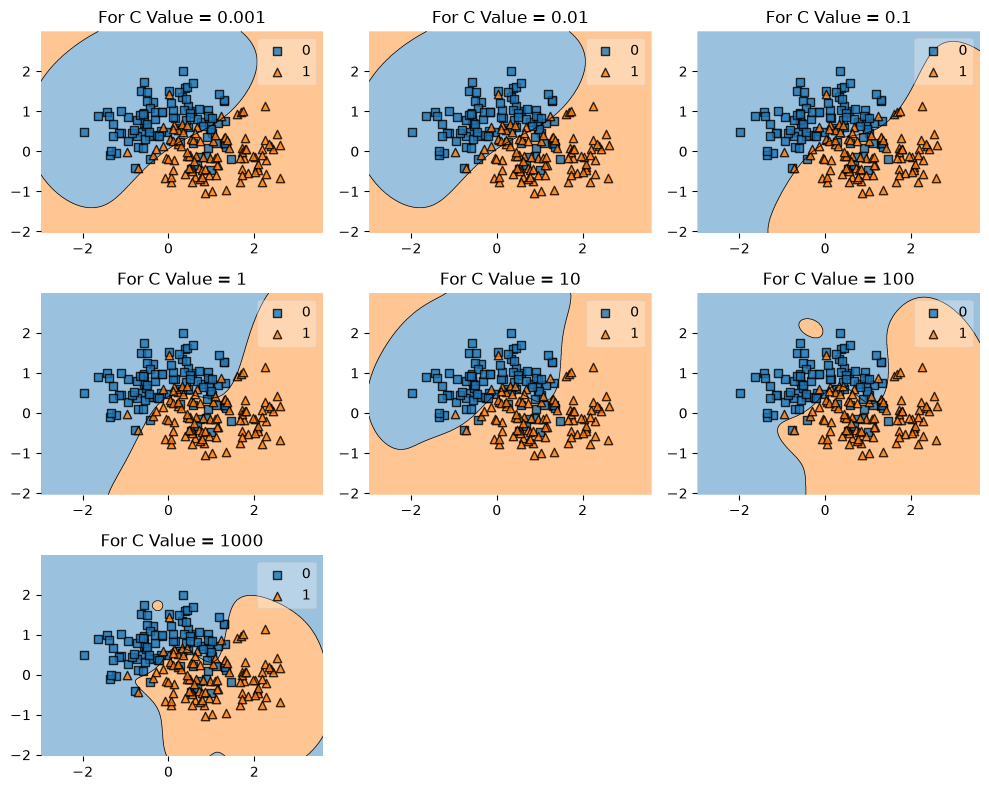

In [64]:
import matplotlib.pyplot as plt

c_values=[0.001, 0.01, 0.1, 1,10 ,100 ,1000]
plt.figure(figsize=(10, 8))
# ax=plt.subplot(3, 3, 1)   # 2 rows, 2 columns, plot number i
# print(ax)
for i, c_value in enumerate(c_values, 1):
    ax=plt.subplot(3, 3, i)   # 2 rows, 2 columns, plot number i
    clf = SVC(C=c_value,kernel="rbf")
    clf.fit(X,y)
    plot_decision_regions(X,y,clf,ax=ax)
    
    plt.title(f"For C Value = {c_value}")

plt.tight_layout()
plt.show()

### 3 Create a dataset where class boundaries are circular (not linear). Show that a linear SVM fails. Compute the RBF kernel matrix and show that the classes become separable in the kernel-induced feature space.

In [65]:
from sklearn.datasets import make_circles

In [66]:
X,y = make_circles(n_samples=100,noise=0.1)
plt.scatter(X[:,0],X[:,1],c=y)

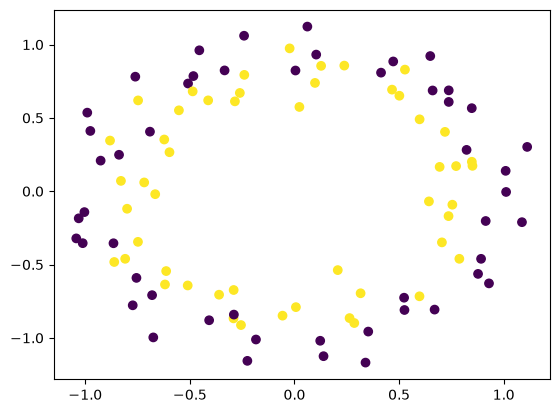

In [70]:
plt.scatter(X[:,0],X[:,1],c=y)

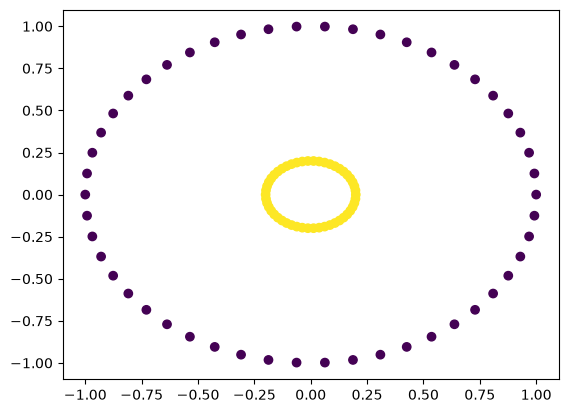

In [71]:
X,y = make_circles(n_samples=100,factor=0.2)
plt.scatter(X[:,0],X[:,1],c=y)

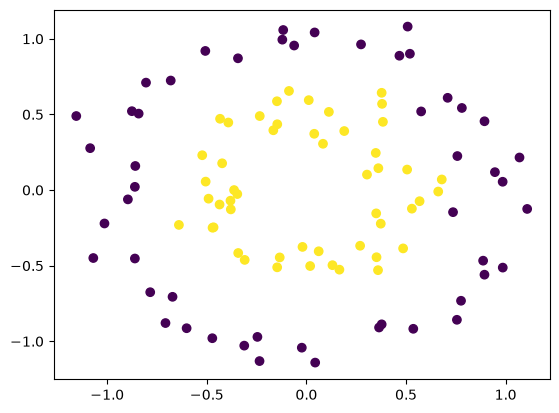

In [74]:
X,y = make_circles(n_samples=100,noise=0.1, factor=0.5)
plt.scatter(X[:,0],X[:,1],c=y)

In [75]:
linear_kernel = SVC(C=1.0 , kernel="linear")
linear_kernel.fit(X,y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [76]:
rbf_kernel = SVC(C=1.0 , kernel="rbf")
rbf_kernel.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


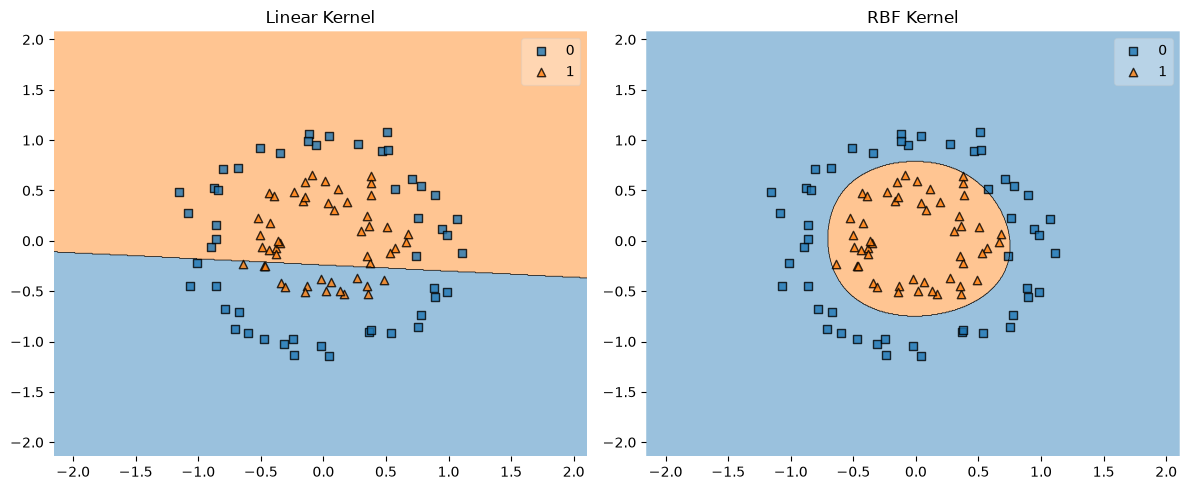

In [79]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear kernel
plot_decision_regions(X, y, clf=linear_kernel, ax=axes[0])
axes[0].set_title("Linear Kernel")

# RBF kernel
plot_decision_regions(X, y, clf=rbf_kernel, ax=axes[1])
axes[1].set_title("RBF Kernel")

plt.tight_layout()
plt.show()

### 4. Compare hinge loss vs logistic loss on the same dataset. Train a linear SVM and logistic regression. Count how many training points contribute to each model's decision boundary (support vectors vs all points).

In [80]:
# svc by deafult use hinge loss and logistic reg uses by deafult log loss
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [83]:
X,y=make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
)

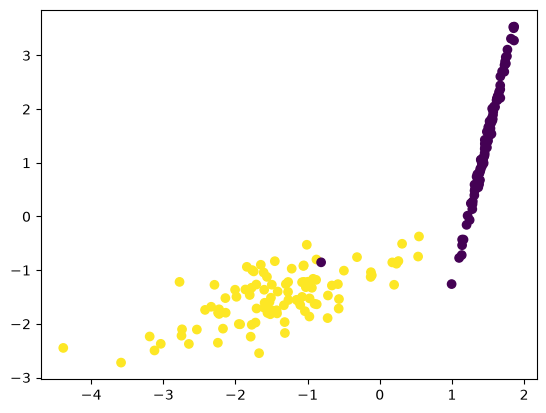

In [88]:
import matplotlib.pyplot as plt 
plt.scatter(X[:,0],X[:,1],c=y)

In [89]:
lg_model=LogisticRegression()
lg_model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [90]:
svc_model=SVC(C=1.0)
svc_model.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


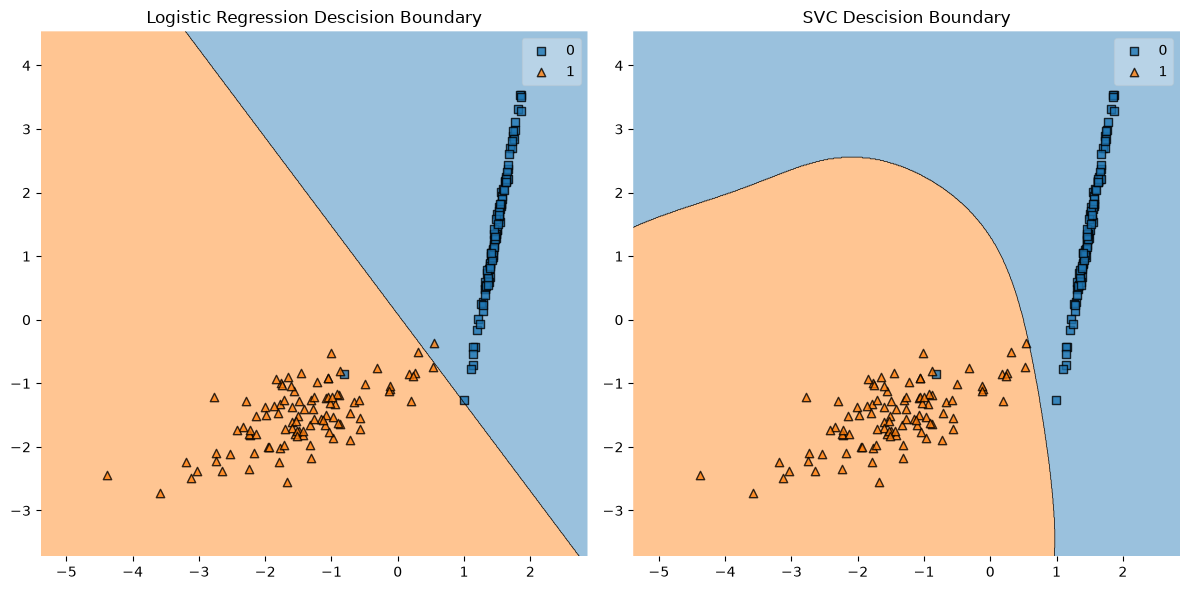

In [98]:
fig,axes = plt.subplots(1,2,figsize=(12,6))

axes[0].set_title("Logistic Regression Descision Boundary")
plot_decision_regions(X,y,lg_model ,ax=axes[0])

axes[1].set_title("SVC Descision Boundary")
plot_decision_regions(X,y,svc_model , ax=axes[1])

plt.tight_layout()
plt.show()

In [99]:
# /preds
lg_pred=lg_model.predict(X_test)
svc_pred=svc_model.predict(X_test)

In [102]:
print("SVM Accuracy:", accuracy_score(y_test, svc_pred))
print("Logistic Accuracy:", accuracy_score(y_test, lg_pred))


SVM Accuracy: 0.38
Logistic Accuracy: 0.38


In [103]:
print("SVM Accuracy On Traiining Data :", accuracy_score(y_train,svc_model.predict(X_train) ))
print("Logistic Accuracy On Traiining Data :", accuracy_score(y_train,lg_model.predict(X_train) ))


SVM Accuracy On Traiining Data : 0.31
Logistic Accuracy On Traiining Data : 0.31


In [104]:
# Count contributing points
sv_count = len(svc_model.support_)
lr_count = len(X)

print("\nSupport vectors (SVM):", sv_count)
print("Training points used by Logistic Regression:", lr_count)


Support vectors (SVM): 20
Training points used by Logistic Regression: 200


In [105]:
svc_model.support_
svc_model.support_vectors_
svc_model.n_support_


array([ 24,  40,  64,  98, 105, 179, 182, 189, 195,  12,  33,  34,  38,
        56,  63,  66,  80,  94,  96, 137], dtype=int32)

In [106]:
svc_model.support_vectors_

array([[ 1.86233276,  3.53652416],
       [ 1.20255155, -0.15650823],
       [ 1.160193  , -0.43089985],
       [ 1.14081045, -0.43018672],
       [ 0.9952295 , -1.25949543],
       [ 1.14052138, -0.53564273],
       [ 1.13559439, -0.71876491],
       [-0.81335349, -0.85413433],
       [ 1.09920441, -0.7724968 ],
       [ 0.19849177, -1.27271411],
       [ 0.17300644, -0.85566791],
       [-2.77521714, -1.21873663],
       [ 0.54311905, -0.37284033],
       [ 0.25763918, -0.83080884],
       [ 0.30890917, -0.50905556],
       [-1.67286353, -2.54679599],
       [ 0.23120464, -0.88021223],
       [-3.5856298 , -2.72192257],
       [ 0.53100889, -0.74677703],
       [-4.38657187, -2.44843548]])

In [107]:
svc_model.n_features_in_

2

In [108]:
svc_model.n_support_

array([ 9, 11], dtype=int32)

- ```support_ ```→ indices of support vectors.
- ```support_vectors_ ```→ feature values of support vectors.
- ```n_support_ ```→ count of support vectors in each class.

### 5 Implement SVR (epsilon-insensitive loss). Fit it to y = sin(x) + noise. Plot the epsilon tube around the predictions and highlight the support vectors (points outside the tube). what is this ?


In [118]:
from sklearn.svm import SVR

In [110]:
X = [i for i in range(150)]


In [114]:
import math
y=[math.sin(x)+0.01 for x in X]

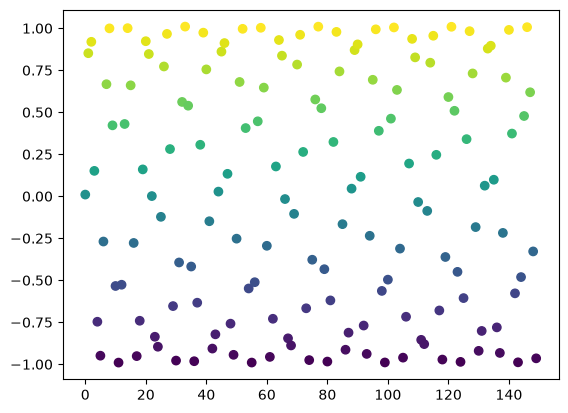

In [120]:
plt.scatter(X,y,c=y)

In [123]:
clf_svr=SVR(epsilon=0.2)

In [126]:
X = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.15, 100)


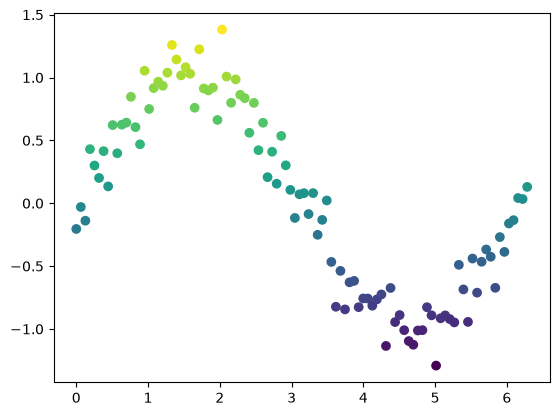

In [129]:
plt.scatter(X,y,c=y)


In [130]:
epsilon = 0.2
svr = SVR(kernel="rbf", C=10, epsilon=epsilon)
svr.fit(X, y)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.2
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [131]:
y_pred=svr.predict(X)

In [145]:
support_vectors=svr.support_

In [146]:
support_vectors

array([ 1,  6, 13, 14, 20, 23, 31, 37, 47, 49, 54, 71, 73, 74, 79, 82, 97],
      dtype=int32)

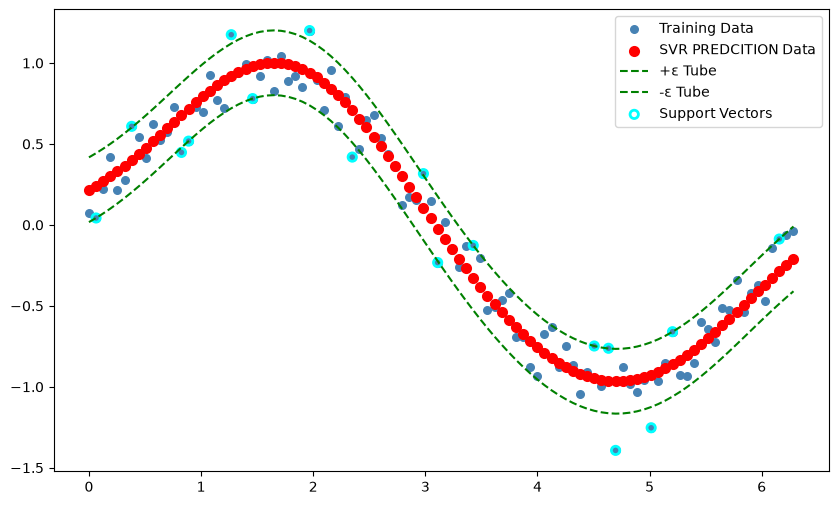

In [147]:
plt.figure(figsize=(10,6))

# original data
plt.scatter(X,y,color="steelblue",s=30,label="Training Data")
# predictionc curve
plt.scatter(X,y_pred,color="red",linewidths=2,label="SVR PREDCITION Data")


# epsilon tube
plt.plot(X, y_pred + epsilon, "g--", linewidth=1.5, label="+ε Tube")
plt.plot(X, y_pred - epsilon, "g--", linewidth=1.5, label="-ε Tube")
plt.scatter(X[support_vectors],y[support_vectors] ,facecolors="none",edgecolors="cyan",linewidths=2,label="Support Vectors",
)
plt.legend()

In [143]:
print("Total training points :", len(X))
print("Support vectors       :", len(svr.support_))
print("Support vector indices:", svr.support_)

Total training points : 100
Support vectors       : 26
Support vector indices: [ 2  3  7  8 14 15 21 26 27 31 32 42 45 48 52 55 57 59 68 69 79 84 86 87
 92 97]


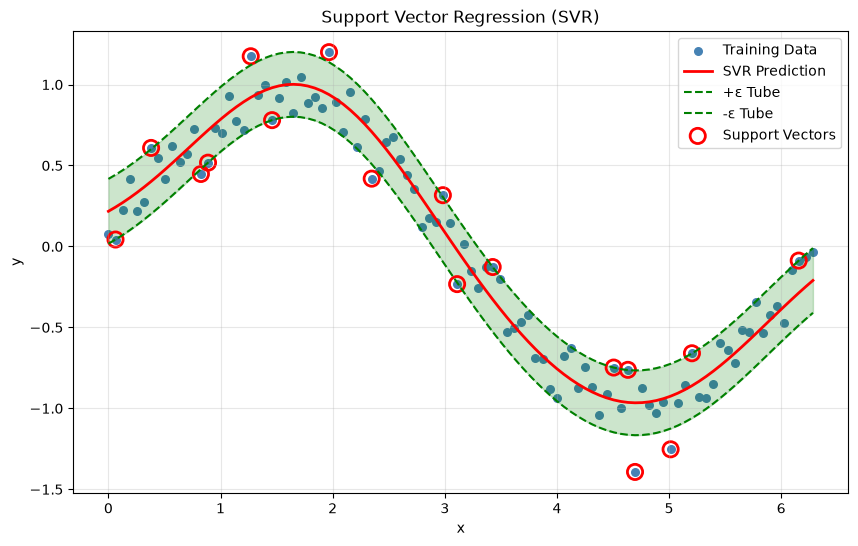

Total training points : 100
Support vectors       : 17
Support vector indices: [ 1  6 13 14 20 23 31 37 47 49 54 71 73 74 79 82 97]


In [144]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Generate data: y = sin(x) + noise
np.random.seed(42)

X = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.15, 100)

# Train SVR
epsilon = 0.2
svr = SVR(kernel="rbf", C=10, epsilon=epsilon)
svr.fit(X, y)

# Predictions
y_pred = svr.predict(X)

# Support vectors
support_vectors = svr.support_

# Plot
plt.figure(figsize=(10, 6))

# Original data
plt.scatter(X, y, color="steelblue", s=30, label="Training Data")

# Prediction curve
plt.plot(X, y_pred, color="red", linewidth=2, label="SVR Prediction")

# Epsilon tube
plt.plot(X, y_pred + epsilon, "g--", linewidth=1.5, label="+ε Tube")
plt.plot(X, y_pred - epsilon, "g--", linewidth=1.5, label="-ε Tube")

# Fill tube
plt.fill_between(
    X.ravel(),
    y_pred - epsilon,
    y_pred + epsilon,
    color="green",
    alpha=0.2,
)

# Highlight support vectors
plt.scatter(
    X[support_vectors],
    y[support_vectors],
    s=120,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Support Vectors",
)

plt.title("Support Vector Regression (SVR)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("Total training points :", len(X))
print("Support vectors       :", len(svr.support_))
print("Support vector indices:", svr.support_)